# 미니프로젝트 6: Day 1~6 통합 복습 (Vibe Coding)

#### <목표>
Day1 ~ 6에서 배운 머신러닝 프로세스 전체를 새로운 데이터셋(신용카드 고객 채무불이행)에 자유롭게 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Default of Credit Card Clients (대만 신용카드 고객 채무불이행 데이터)
- 30,000명의 신용카드 고객 정보로 다음 달 채무불이행 여부를 예측

| 변수명 | 설명 |
|:---:|:---|
| LIMIT_BAL | 신용한도 |
| SEX, EDUCATION, MARRIAGE, AGE | 고객 인적사항 |
| PAY_0, PAY_2~PAY_6 | 최근 6개월 월별 연체 상태 (-1: 정상납부, 1 이상: 연체 개월 수) |
| BILL_AMT1~6 | 최근 6개월 청구액 |
| PAY_AMT1~6 | 최근 6개월 납부액 |
| default payment next month | 다음 달 채무불이행 여부 (1: 불이행, 0: 정상) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `default payment next month` | 고객 정보로 다음 달 채무불이행 여부 예측 |

1. 각 섹션의 **과제**를 읽고, Day1~6 중 어떤 내용을 적용해야 할지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day6_miniproject.csv` 파일을 사용하기
- 타겟 변수: `default payment next month` (0: 정상, 1: 채무불이행)

**[과제]** 써니는 신용카드 고객 채무불이행 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리와 데이터를 불러오는 코드를 AI와 상의해서 작성하세요.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"   # macOS
plt.rcParams["axes.unicode_minus"] = False    # 마이너스 기호 깨짐 방지

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 분할 / 하이퍼파라미터 튜닝
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold,
)

# 전처리
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer

# 단일 모델
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 앙상블 모델
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 평가 지표
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

# 클래스 불균형 처리 (Day 4)
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

# 변수 선택 & 모델 해석 (Day 5~6, 이후 섹션에서 사용)
# !pip install mrmr-selection boruta shap stucco imbalanced-learn xgboost lightgbm catboost
from mrmr import mrmr_classif
from boruta import BorutaPy
import shap
from stucco import ContrastSetLearner

In [3]:
# 타겟 변수
TARGET = "default payment next month"   # 0: 정상, 1: 채무불이행

# 데이터 로드
data = pd.read_csv("dataset/day6_miniproject.csv")

# 기본 정보 확인
print("데이터 크기:", data.shape)
print("\n컬럼 목록:")
print(data.columns.tolist())
print("\n타겟 분포:")
print(data[TARGET].value_counts())
print("\n타겟 비율:")
print(data[TARGET].value_counts(normalize=True).round(4))

data.head()

데이터 크기: (30000, 24)

컬럼 목록:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

타겟 분포:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

타겟 비율:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1) 데이터 탐색 (EDA)

1. Value 기반 탐색 (구조적/통계적)
2. Graph 기반 탐색 (단일 변수/변수 간/여러 변수 간)

**[과제]** 써니는 모델링을 수행하기 전에 필요한 전처리 과정을 파악하기 위해 데이터 탐색(EDA)이 필요하다고 생각했습니다.

AI와 상의하여 데이터의 구조적 정보(변수 타입, 결측치 유무 등)와 통계적 정보(변수별 고유값 개수, 기초통계량 등)를 확인하는 코드를 작성하고, 결과를 분석해 보세요.


In [4]:
# ===== 1. 구조적 정보 =====
TARGET = "default payment next month"

print("=" * 50)
print("1) 데이터 크기")
print("=" * 50)
print("행/열:", data.shape)

print("\n" + "=" * 50)
print("2) 변수 타입")
print("=" * 50)
print(data.dtypes)

print("\n" + "=" * 50)
print("3) 결측치")
print("=" * 50)
missing = data.isnull().sum()
print("전체 결측치 개수:", missing.sum())
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("결측치 없음")

print("\n" + "=" * 50)
print("4) 중복 행")
print("=" * 50)
print("중복 행 개수:", data.duplicated().sum())

print("\n" + "=" * 50)
print("5) 변수별 고유값 개수")
print("=" * 50)
print(data.nunique().sort_values())

print("\n" + "=" * 50)
print("6) 상세 구조 (info)")
print("=" * 50)
data.info()

print("\n" + "=" * 50)
print("7) 데이터 미리보기")
print("=" * 50)
display(data.head())
display(data.tail())

1) 데이터 크기
행/열: (30000, 24)

2) 변수 타입
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

3) 결측치
전체 결측치 개수: 0
결측치 없음

4) 중복 행
중복 행 개수: 35

5) 변수별 고유값 개수
default payment next 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,50000,1,2,1,46,0,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [5]:
# ===== 2. 통계적 정보 =====
TARGET = "default payment next month"

# 범주형(코드형) / 연속형 변수 구분
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"] + [c for c in data.columns if c.startswith("PAY_")]
num_cols = ["LIMIT_BAL", "AGE"] + [c for c in data.columns if "BILL" in c or "PAY_AMT" in c]

print("=" * 50)
print("1) 타겟 변수 분포")
print("=" * 50)
print(data[TARGET].value_counts())
print("\n비율:")
print(data[TARGET].value_counts(normalize=True).round(4))

print("\n" + "=" * 50)
print("2) 수치형 변수 기초통계량")
print("=" * 50)
display(data[num_cols + [TARGET]].describe().T.round(2))

print("\n" + "=" * 50)
print("3) 범주형 변수 빈도")
print("=" * 50)
for col in cat_cols:
    print(f"\n[{col}]")
    print(data[col].value_counts().sort_index())

print("\n" + "=" * 50)
print("4) 타겟과의 상관계수 (절댓값 상위)")
print("=" * 50)
corr_target = (
    data.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
print(corr_target.head(10).round(4))

print("\n" + "=" * 50)
print("5) 이상값 후보 확인")
print("=" * 50)

# EDUCATION, MARRIAGE 정의 밖 코드값
print("EDUCATION 비정상 코드 (0, 5, 6):", data["EDUCATION"].isin([0, 5, 6]).sum())
print("MARRIAGE 비정상 코드 (0, 3):", data["MARRIAGE"].isin([0, 3]).sum())

# BILL_AMT 음수 (환불/조정 가능)
bill_cols = [c for c in data.columns if "BILL" in c]
print("\nBILL_AMT 음수 개수:")
for col in bill_cols:
    print(f"  {col}: {(data[col] < 0).sum()}")

# PAY_AMT = 0 (미납부)
pay_amt_cols = [c for c in data.columns if "PAY_AMT" in c]
print("\nPAY_AMT = 0 개수:")
for col in pay_amt_cols:
    print(f"  {col}: {(data[col] == 0).sum()}")

1) 타겟 변수 분포
default payment next month
0    23364
1     6636
Name: count, dtype: int64

비율:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

2) 수치형 변수 기초통계량


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.33,73635.86,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.08,71173.77,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.15,69349.39,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.95,64332.86,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.40,60797.16,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.76,59554.11,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.58,16563.28,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.16,23040.87,0.0,833.00,2009.0,5000.00,1684259.0



3) 범주형 변수 빈도

[SEX]
SEX
1    11888
2    18112
Name: count, dtype: int64

[EDUCATION]
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

[MARRIAGE]
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

[PAY_0]
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

[PAY_2]
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

[PAY_3]
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

[PAY_4]
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

[PAY_5]
PAY_5
-2 

**[과제]** 써니는 데이터의 분포에 따라 필요한 전처리와 분석 방법이 달라질 수 있다고 생각했습니다.

AI와 상의하여 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요한지 탐구해 보세요.

In [6]:
TARGET = "default payment next month"

print("shape:", data.shape)
print("결측:", data.isnull().sum().sum())
print("중복:", data.duplicated().sum())
data.info()
display(data.head())
display(data.nunique().sort_values())
display(data.describe().T.round(2))
print(data[TARGET].value_counts(normalize=True))

shape: (30000, 24)
결측: 0
중복: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   3

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


default payment next month        2
SEX                               2
MARRIAGE                          4
EDUCATION                         7
PAY_5                            10
PAY_6                            10
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
AGE                              56
LIMIT_BAL                        81
PAY_AMT5                       6897
PAY_AMT4                       6937
PAY_AMT6                       6939
PAY_AMT3                       7518
PAY_AMT2                       7899
PAY_AMT1                       7943
BILL_AMT6                     20604
BILL_AMT5                     21010
BILL_AMT4                     21548
BILL_AMT3                     22026
BILL_AMT2                     22346
BILL_AMT1                     22723
dtype: int64

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0


default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

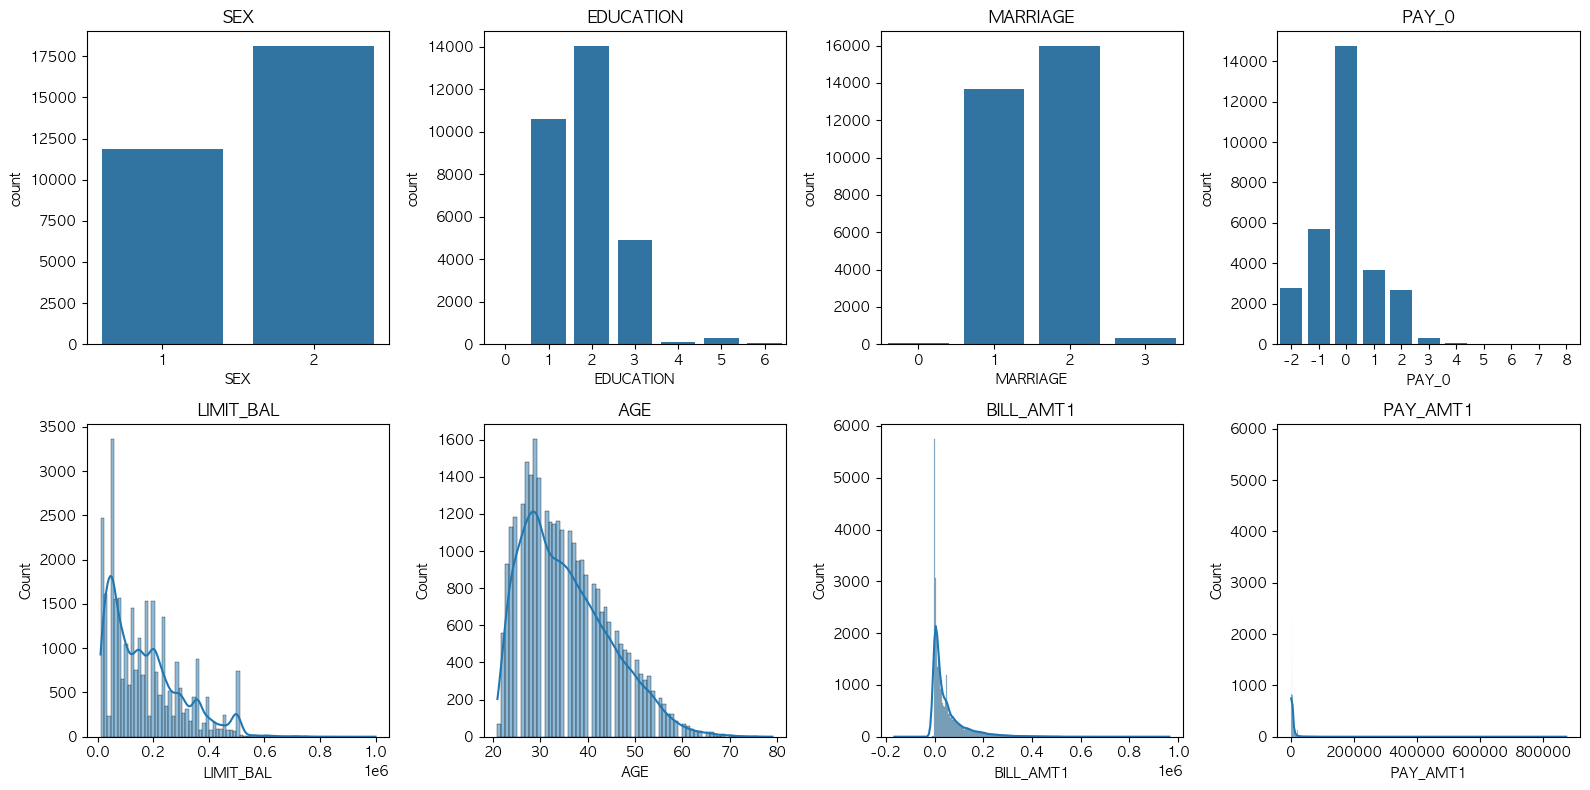

In [7]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]
num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes[0], cat_cols):
    sns.countplot(data=data, x=col, order=sorted(data[col].unique()), ax=ax)
    ax.set_title(col)

for ax, col in zip(axes[1], num_cols):
    sns.histplot(data=data, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

---

## 2) 데이터 전처리

1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1)

**[과제]** 써니는 EDA 결과를 바탕으로 모델링에 필요한 전처리 과정을 계획하고자 합니다.

AI와 상의하여 필요한 전처리 항목을 나열한 뒤, 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해 보세요. 

이후 올바른 순서에 따라 전처리를 진행해 보세요.

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = "default payment next month"

# ===== [분할 전] 1. 중복 제거 =====
df = data.drop_duplicates().copy()
print("중복 제거 후:", df.shape)

# ===== [분할 전] 2. 범주 코드 정리 =====
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})   # others
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})                 # others

# ===== [분할 전] 3. BILL 음수 → 0 =====
bill_cols = [c for c in df.columns if "BILL" in c]
df[bill_cols] = df[bill_cols].clip(lower=0)

# ===== [분할 전] 4. log 변환 (금액 변수) =====
log_cols = ["LIMIT_BAL"] + bill_cols + [c for c in df.columns if "PAY_AMT" in c]
for col in log_cols:
    df[col] = np.log1p(df[col])

# ===== [분할 전] 5. X / y 분리 =====
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ===== [분할 전] 6. Train / Test 분할 =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, "test:", X_test.shape)
print("train 타겟:\n", y_train.value_counts(normalize=True).round(3))

# ===== [분할 후] 7. 스케일링 (train fit) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("전처리 완료")
print("- X_train (원본):", X_train.shape)
print("- X_train_scaled:", X_train_scaled.shape)
print("- X_test_scaled:", X_test_scaled.shape)

중복 제거 후: (29965, 24)
train: (23972, 23) test: (5993, 23)
train 타겟:
 default payment next month
0    0.779
1    0.221
Name: proportion, dtype: float64
전처리 완료
- X_train (원본): (23972, 23)
- X_train_scaled: (23972, 23)
- X_test_scaled: (5993, 23)


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = "default payment next month"

# --- 분할 전 ---
df = data.drop_duplicates().copy()

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

bill_cols = [c for c in df.columns if "BILL" in c]
df[bill_cols] = df[bill_cols].clip(lower=0)

log_cols = ["LIMIT_BAL"] + bill_cols + [c for c in df.columns if "PAY_AMT" in c]
for col in log_cols:
    df[col] = np.log1p(df[col])

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 분할 후 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("train:", X_train.shape, "| test:", X_test.shape)
print("train 타겟:\n", y_train.value_counts(normalize=True).round(3))

train: (23972, 23) | test: (5993, 23)
train 타겟:
 default payment next month
0    0.779
1    0.221
Name: proportion, dtype: float64


---

## 3) 모델링 및 모델 고도화

1. 단일 모델 (Logistic Regression, Decision Tree)
2. 앙상블 모델 (Random Forest, GBM, XGBoost, LightGBM, CatBoost)

**[과제]** 써니는 본 데이터에 가장 적합한 분류 모델이 무엇인지 알아보고자 합니다.

AI와 상의하여 다양한 분류 모델을 선정하고 학습시키는 코드를 작성한 뒤, Accuracy, Precision, Recall, F1-score, AUC-ROC 등의 분류 평가 지표를 활용하여 모델별 성능을 비교해 보세요.

In [10]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, X_test_scaled),
    ("Decision Tree",       DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test),
    ("Random Forest",       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train, X_test),
    ("GBM",                 GradientBoostingClassifier(random_state=42), X_train, X_test),
    ("XGBoost",             XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42, n_jobs=-1), X_train, X_test),
    ("LightGBM",            LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1), X_train, X_test),
    ("CatBoost",            CatBoostClassifier(n_estimators=100, random_state=42, verbose=0), X_train, X_test),
]

results = []
for name, model, Xtr, Xte in models:
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, prob),
    })

result_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False).round(4)
result_df

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
3,GBM,0.8178,0.6639,0.3575,0.4647,0.7726
5,LightGBM,0.8211,0.6774,0.3658,0.4750,0.7724
6,CatBoost,0.8161,0.6489,0.3680,0.4697,0.7665
4,XGBoost,0.8129,0.6383,0.3567,0.4577,0.7586
2,Random Forest,0.8124,0.6340,0.3605,0.4596,0.7576
1,Decision Tree,0.8161,0.6547,0.3575,0.4624,0.7439
0,Logistic Regression,0.8081,0.6803,0.2504,0.3660,0.7390


**[과제]** 써니는 모델의 성능을 더욱 향상시키고자 합니다.

AI와 상의하여 Grid Search 또는 Random Search를 활용한 하이퍼파라미터 튜닝 코드를 작성하고, 튜닝 전후의 모델 성능을 비교해 보세요.

In [11]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 튜닝 대상: XGBoost (result_df 1위 모델로 변경 가능)
base_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()  # 불균형 보정
)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 1, 2],
    "reg_lambda": [1, 3, 5],
}

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=20,           # Random Search 시도 횟수
    cv=3,
    scoring="f1",        # 불균형 → F1 기준
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("최적 파라미터:", search.best_params_)
print("CV F1:", round(search.best_score_, 4))

best_model = search.best_estimator_

최적 파라미터: {'subsample': 0.8, 'reg_lambda': 3, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
CV F1: 0.5439


In [12]:
def evaluate(model, Xtr, Xte, ytr, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC-ROC": roc_auc_score(yte, prob),
    }

before = evaluate(
    XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "Before Tuning"
)

after = evaluate(best_model, X_train, X_test, y_train, y_test, "After Tuning")

compare_tune = pd.DataFrame([before, after]).round(4)
compare_tune

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Before Tuning,0.8129,0.6383,0.3567,0.4577,0.7586
1,After Tuning,0.7621,0.4708,0.6078,0.5306,0.7714


**[과제]** 써니는 변수 선택이 모델 성능 향상에 도움이 되는지 궁금해졌습니다.

AI와 상의하여 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta 등)을 결정하고 관련 코드를 작성해 보세요.

이후 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해 보세요.

In [13]:
import pandas as pd
from mrmr import mrmr_classif
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# mRMR 변수 선택 (train만 사용)
K = 10
selected_features = mrmr_classif(X=X_train, y=y_train, K=K, show_progress=False)
print(f"mRMR 선택 변수 ({len(selected_features)}개):", selected_features)

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

mRMR 선택 변수 (10개): ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3', 'LIMIT_BAL', 'PAY_AMT2', 'PAY_4', 'PAY_5', 'PAY_AMT3']


In [14]:
def evaluate_xgb(Xtr, Xte, ytr, yte, label):
    model = XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=(ytr == 0).sum() / (ytr == 1).sum(),
        **search.best_params_   # 튜닝 파라미터 재사용 (없으면 해당 줄 삭제)
    )
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {
        "Method": label,
        "Features": Xtr.shape[1],
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC-ROC": roc_auc_score(yte, prob),
    }

compare_fs = pd.DataFrame([
    evaluate_xgb(X_train, X_test, y_train, y_test, f"전체 변수 ({X_train.shape[1]}개)"),
    evaluate_xgb(X_train_sel, X_test_sel, y_train, y_test, f"mRMR ({len(selected_features)}개)"),
]).round(4)

compare_fs

,Method,Features,Accuracy,Precision,Recall,F1,AUC-ROC
0,전체 변수 (23개),23,0.7621,0.4708,0.6078,0.5306,0.7714
1,mRMR (10개),10,0.7522,0.4550,0.6056,0.5196,0.7623


In [15]:
import pandas as pd
import numpy as np
from mrmr import mrmr_classif
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_candidates = [3, 5, 7, 10, 12, 15, 18, 20, 23]  # 23 = 전체 변수 수
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
)

cv_results = []
selected_by_k = {}

for k in k_candidates:
    selected = mrmr_classif(X=X_train, y=y_train, K=k, show_progress=False)
    selected_by_k[k] = selected

    X_tr = X_train[selected]
    cv_f1 = cross_val_score(xgb_cv, X_tr, y_train, cv=cv, scoring="f1").mean()
    cv_auc = cross_val_score(xgb_cv, X_tr, y_train, cv=cv, scoring="roc_auc").mean()

    cv_results.append({
        "K": k,
        "n_features": len(selected),
        "CV_F1": cv_f1,
        "CV_AUC": cv_auc,
        "selected": selected,
    })
    print(f"K={k:2d} | CV F1={cv_f1:.4f} | CV AUC={cv_auc:.4f} | {selected}")

cv_df = pd.DataFrame(cv_results).sort_values("CV_F1", ascending=False)
best_k = cv_df.iloc[0]["K"]
print(f"\nCV 기준 최적 K: {best_k}")
cv_df[["K", "n_features", "CV_F1", "CV_AUC"]].round(4)

K= 3 | CV F1=0.5072 | CV AUC=0.7290 | ['PAY_0', 'PAY_AMT5', 'PAY_2']
K= 5 | CV F1=0.5041 | CV AUC=0.7434 | ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3']
K= 7 | CV F1=0.5098 | CV AUC=0.7498 | ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3', 'LIMIT_BAL', 'PAY_AMT2']
K=10 | CV F1=0.5169 | CV AUC=0.7546 | ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3', 'LIMIT_BAL', 'PAY_AMT2', 'PAY_4', 'PAY_5', 'PAY_AMT3']
K=12 | CV F1=0.5143 | CV AUC=0.7550 | ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3', 'LIMIT_BAL', 'PAY_AMT2', 'PAY_4', 'PAY_5', 'PAY_AMT3', 'PAY_6', 'PAY_AMT4']
K=15 | CV F1=0.5141 | CV AUC=0.7518 | ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3', 'LIMIT_BAL', 'PAY_AMT2', 'PAY_4', 'PAY_5', 'PAY_AMT3', 'PAY_6', 'PAY_AMT4', 'PAY_AMT6', 'SEX', 'MARRIAGE']
K=18 | CV F1=0.5142 | CV AUC=0.7589 | ['PAY_0', 'PAY_AMT5', 'PAY_2', 'PAY_AMT1', 'PAY_3', 'LIMIT_BAL', 'PAY_AMT2', 'PAY_4', 'PAY_5', 'PAY_AMT3', 'PAY_6', 'PAY_AMT4', 'PAY_AMT6', 'SEX', 'MARRIAGE', 'EDUCATION', 'BILL_AM

,K,n_features,CV_F1,CV_AUC
8,23,23,0.5185,0.7600
3,10,10,0.5169,0.7546
4,12,12,0.5143,0.7550
6,18,18,0.5142,0.7589
5,15,15,0.5141,0.7518
7,20,20,0.5113,0.7582
2,7,7,0.5098,0.7498
0,3,3,0.5072,0.7290
1,5,5,0.5041,0.7434


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def eval_model(Xtr, Xte, ytr, yte):
    model = XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=(ytr == 0).sum() / (ytr == 1).sum(),
    )
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC-ROC": roc_auc_score(yte, prob),
    }

test_results = []

# baseline: 전체 변수
m = eval_model(X_train, X_test, y_train, y_test)
test_results.append({"Method": f"전체 ({X_train.shape[1]}개)", "K": X_train.shape[1], **m})

# K별 mRMR
for k in k_candidates:
    cols = selected_by_k[k]
    m = eval_model(X_train[cols], X_test[cols], y_train, y_test)
    test_results.append({"Method": f"mRMR K={k}", "K": k, **m})

test_df = pd.DataFrame(test_results).round(4)
test_df.sort_values("F1", ascending=False)

,Method,K,Accuracy,Precision,Recall,F1,AUC-ROC
8,mRMR K=20,20,0.7554,0.4581,0.5777,0.5110,0.7501
7,mRMR K=18,18,0.7537,0.4548,0.5694,0.5057,0.7536
6,mRMR K=15,15,0.7480,0.4463,0.5769,0.5033,0.7474
0,전체 (23개),23,0.7519,0.4515,0.5656,0.5022,0.7490
9,mRMR K=23,23,0.7547,0.4557,0.5581,0.5017,0.7560
5,mRMR K=12,12,0.7475,0.4449,0.5694,0.4995,0.7454
4,mRMR K=10,10,0.7467,0.4435,0.5679,0.4980,0.7453
2,mRMR K=5,5,0.7375,0.4314,0.5852,0.4966,0.7393
1,mRMR K=3,3,0.7634,0.4686,0.5173,0.4918,0.7208
3,mRMR K=7,7,0.7395,0.4327,0.5694,0.4917,0.7433


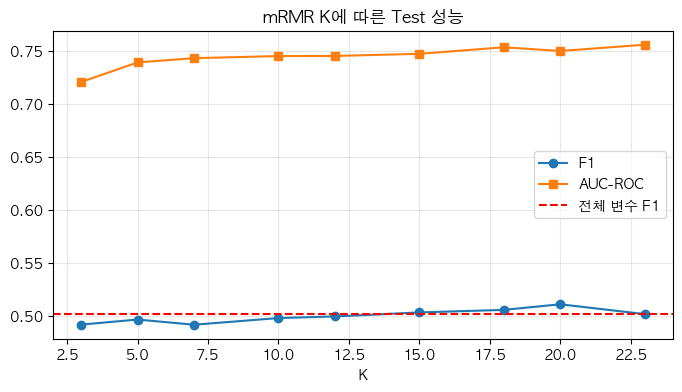

In [17]:
import matplotlib.pyplot as plt

plot_df = test_df[test_df["Method"] != f"전체 ({X_train.shape[1]}개)"]

plt.figure(figsize=(8, 4))
plt.plot(plot_df["K"], plot_df["F1"], marker="o", label="F1")
plt.plot(plot_df["K"], plot_df["AUC-ROC"], marker="s", label="AUC-ROC")
plt.axhline(test_df.loc[0, "F1"], color="red", linestyle="--", label="전체 변수 F1")
plt.xlabel("K")
plt.title("mRMR K에 따른 Test 성능")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**[과제]** 써니는 클래스 불균형을 완화하면 모델 성능이 향상될 것이라고 생각했습니다.

AI와 상의하여 Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해 보세요.

이후 적용 전후의 모델 성능을 비교해 보세요.

In [18]:
import pandas as pd
import numpy as np
from mrmr import mrmr_classif
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

# mRMR K=20 변수
selected_k20 = mrmr_classif(X=X_train, y=y_train, K=20, show_progress=False)
X_tr = X_train[selected_k20].values
X_te = X_test[selected_k20].values
y_tr = y_train.values

# Resampling (train만)
datasets = {
    "Before": (X_tr, y_tr),
    "TomekLinks": TomekLinks().fit_resample(X_tr, y_tr),
    "SMOTE": SMOTE(random_state=42).fit_resample(X_tr, y_tr),
    "SMOTE+Tomek": SMOTETomek(random_state=42).fit_resample(X_tr, y_tr),
    "ADASYN": ADASYN(random_state=42).fit_resample(X_tr, y_tr),
}

for name, (_, y_res) in datasets.items():
    print(name, pd.Series(y_res).value_counts().to_dict())

Before {0: 18668, 1: 5304}
TomekLinks {0: 17313, 1: 5304}
SMOTE {0: 18668, 1: 18668}
SMOTE+Tomek {0: 18458, 1: 18458}
ADASYN {0: 18668, 1: 18511}


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_resample(X_train_res, y_train_res, label):
    # Resampling 후에는 scale_pos_weight 불필요
    model = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)
    model.fit(X_train_res, y_train_res)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    return {
        "Method": label,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, prob),
    }

compare_resample = pd.DataFrame([
    evaluate_resample(X, y, name) for name, (X, y) in datasets.items()
]).round(4)

compare_resample.sort_values("F1", ascending=False)

,Method,Accuracy,Precision,Recall,F1,AUC-ROC
2,SMOTE,0.8119,0.6180,0.3929,0.4804,0.7559
1,TomekLinks,0.8043,0.5827,0.4065,0.4789,0.7550
3,SMOTE+Tomek,0.8108,0.6165,0.3831,0.4726,0.7591
4,ADASYN,0.8091,0.6086,0.3846,0.4713,0.7528
0,Before,0.8116,0.6294,0.3612,0.4590,0.7564


In [20]:
import pandas as pd
import numpy as np
from mrmr import mrmr_classif
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# mRMR K=20
selected_k20 = mrmr_classif(X=X_train, y=y_train, K=20, show_progress=False)
X_tr = X_train[selected_k20].values
X_te = X_test[selected_k20].values
y_tr = y_train.values

# Resampling (train만)
datasets = {
    "Before": (X_tr, y_tr),
    "TomekLinks": TomekLinks().fit_resample(X_tr, y_tr),
    "SMOTE": SMOTE(random_state=42).fit_resample(X_tr, y_tr),
    "SMOTE+Tomek": SMOTETomek(random_state=42).fit_resample(X_tr, y_tr),
    "ADASYN": ADASYN(random_state=42).fit_resample(X_tr, y_tr),
}

def make_model(y_train_res):
    params = search.best_params_.copy()
    # Resampling 후에는 불균형 보정 파라미터 제거
    params.pop("scale_pos_weight", None)
    return XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        **params
    )

def evaluate_resample(X_train_res, y_train_res, label):
    model = make_model(y_train_res)
    model.fit(X_train_res, y_train_res)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    return {
        "Method": label,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, prob),
    }

compare_resample = pd.DataFrame([
    evaluate_resample(X, y, name) for name, (X, y) in datasets.items()
]).round(4)

compare_resample.sort_values("F1", ascending=False)

,Method,Accuracy,Precision,Recall,F1,AUC-ROC
3,SMOTE+Tomek,0.8079,0.5864,0.4480,0.5079,0.7623
2,SMOTE,0.8084,0.5886,0.4457,0.5073,0.7619
4,ADASYN,0.8094,0.5991,0.4193,0.4933,0.7611
1,TomekLinks,0.8196,0.6676,0.3680,0.4745,0.7693
0,Before,0.8183,0.6939,0.3198,0.4378,0.7704


## 6) 모델 해석

1. SHAP Value
2. Clustering 기반 RCA
3. STUCCO 기반 RCA

**[과제]** 써니는 최종 모델의 예측 결과를 해석하고자 합니다.

가장 예측력이 좋았던 전처리 방법, 모델, 모델 고도화 방법의 조합을 선택한 뒤, AI와 상의하여 적절한 모델 해석 기법을 적용해 보세요.

이를 바탕으로 "어떤 고객이 채무불이행 위험이 높은지"를 한 문단으로 정리해 보세요.

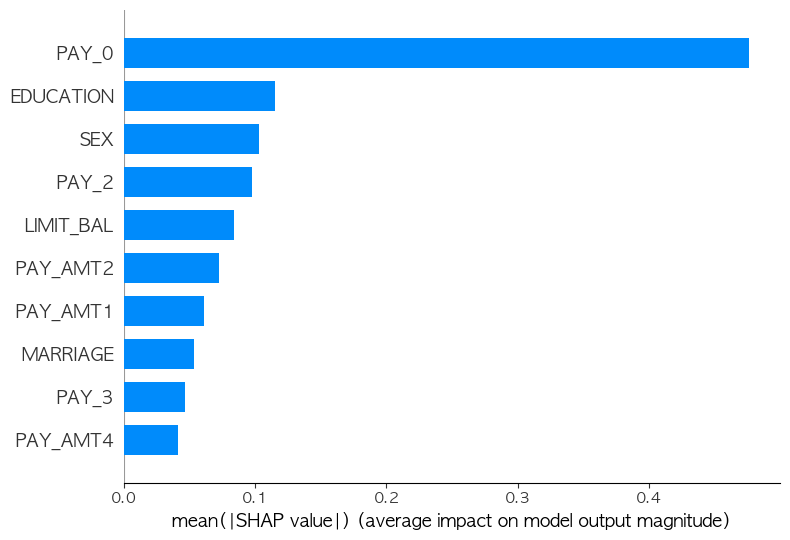

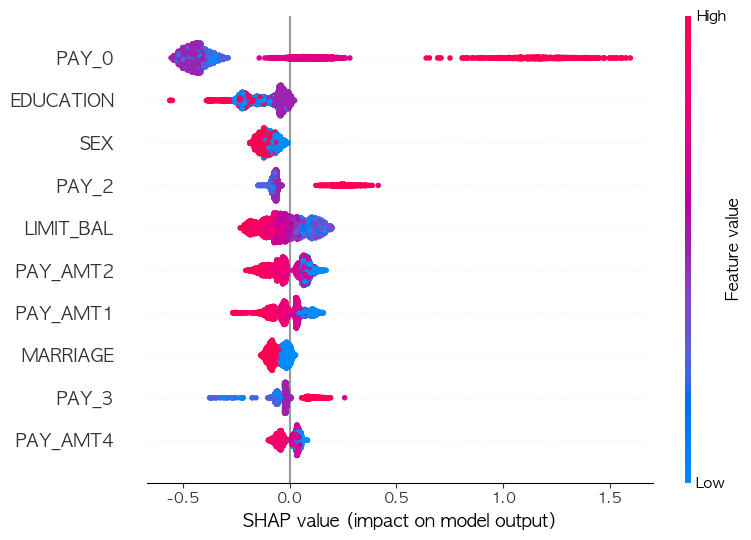

,feature,mean_|SHAP|
0,PAY_0,0.475819
15,EDUCATION,0.114831
13,SEX,0.102994
2,PAY_2,0.097898
5,LIMIT_BAL,0.083713
6,PAY_AMT2,0.072663
3,PAY_AMT1,0.060768
14,MARRIAGE,0.053602
4,PAY_3,0.046622
11,PAY_AMT4,0.041542


In [21]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mrmr import mrmr_classif
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

# ── 최종 조합: mRMR K=20 + SMOTE+Tomek + 튜닝 XGBoost ──
selected_k20 = mrmr_classif(X=X_train, y=y_train, K=20, show_progress=False)
X_tr_df = X_train[selected_k20]
X_te_df = X_test[selected_k20]

X_res, y_res = SMOTETomek(random_state=42).fit_resample(X_tr_df.values, y_train.values)

params = search.best_params_.copy()
params.pop("scale_pos_weight", None)

final_model = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, **params)
final_model.fit(X_res, y_res)

# ── SHAP ──
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_te_df)

# XGBoost 버전에 따라 shape 다름 → 불이행(1) 클래스 SHAP 추출
if isinstance(shap_values, list):
    shap_default = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_default = shap_values[:, :, 1]
else:
    shap_default = shap_values

# 변수 중요도 (bar)
shap.summary_plot(shap_default, X_te_df, plot_type="bar", max_display=10)

# 변수값 vs 영향력 (beeswarm)
shap.summary_plot(shap_default, X_te_df, max_display=10)

# 상위 변수 확인
importance = pd.DataFrame({
    "feature": selected_k20,
    "mean_|SHAP|": np.abs(shap_default).mean(axis=0)
}).sort_values("mean_|SHAP|", ascending=False)

importance.head(10)

SHAP 분석 결과, 채무불이행 예측에 압도적으로 큰 영향을 미치는 변수는 **최근 연체 상태(PAY_0, mean |SHAP| ≈ 0.47)**입니다. PAY_0 값이 높을수록(최근 1개월 이상 연체) SHAP 값이 +1.5까지 올라가며 불이행 위험이 급증하고, 정상 납부(-1, -2) 구간은 SHAP가 음수로 내려가 위험이 낮게 평가됩니다. 그다음으로 **과거 연체 이력(PAY_2, PAY_3)**이 중요하며, 과거에도 연체가 반복된 고객일수록 위험도가 높아집니다. 납부 행동 측면에서는 PAY_AMT1, PAY_AMT2, PAY_AMT4가 낮을수록 불이행 가능성이 커지고, 청구액 대비 납부가 부족한 패턴이 위험 신호로 작용합니다. **신용한도(LIMIT_BAL)**는 한도가 낮을수록 SHAP가 양(+) 방향으로 기여해, 상대적으로 한도가 낮은 고객의 위험이 더 높게 평가됩니다. 인적 변수 중에서는 **EDUCATION·SEX·MARRIAGE**도 예측에 기여하지만 영향력은 PAY 변수보다 작습니다. 특히 EDUCATION 값이 낮을수록 위험이 다소 높게 나타납니다. 종합하면, 최근·과거 연체 이력이 길고, 납부액이 적으며, 신용한도가 상대적으로 낮은 고객이 채무불이행 고위험군으로 분류됩니다. 반대로 PAY_0가 정상이고 납부액이 충분한 고객은 위험이 낮게 평가됩니다.

**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩